In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
# STEP 1: LOAD DATA
fin = pd.read_csv(r"C:\Users\moham\Downloads\financial_data_raw_100k.csv")

In [5]:
#STEP 1 — INITIAL DATA OVERVIEW
print (f'  {fin.shape[0] } rows x {fin.shape[1]} columns')

  102000 rows x 15 columns


In [6]:
fin.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Transaction_ID      102000 non-null  object 
 1   Date                98607 non-null   object 
 2   Region              102000 non-null  object 
 3   Product_Category    102000 non-null  object 
 4   Sales_Channel       102000 non-null  object 
 5   Customer_Type       102000 non-null  object 
 6   Payment_Method      102000 non-null  object 
 7   Revenue             96913 non-null   float64
 8   Cost_of_Goods_Sold  102000 non-null  float64
 9   Operating_Expenses  102000 non-null  float64
 10  Tax_Rate            102000 non-null  float64
 11  Discount_%          102000 non-null  float64
 12  Returns_Amount      102000 non-null  float64
 13  Units_Sold          102000 non-null  int64  
 14  Sales_Rep           102000 non-null  object 
dtypes: float64(6), int64(1), object(8)

In [7]:
fin.isnull().sum()

Transaction_ID           0
Date                  3393
Region                   0
Product_Category         0
Sales_Channel            0
Customer_Type            0
Payment_Method           0
Revenue               5087
Cost_of_Goods_Sold       0
Operating_Expenses       0
Tax_Rate                 0
Discount_%               0
Returns_Amount           0
Units_Sold               0
Sales_Rep                0
dtype: int64

In [8]:
fin.duplicated().value_counts()

False    100000
True       2000
Name: count, dtype: int64

In [9]:
# STEP 2: FIX DATA TYPES
fin['Date'] = pd.to_datetime(fin['Date'])
fin['Revenue'] = pd.to_numeric(fin['Revenue'], errors='coerce')
fin['Cost_of_Goods_Sold'] = pd.to_numeric(fin['Cost_of_Goods_Sold'], errors='coerce')
fin['Operating_Expenses'] = pd.to_numeric(fin['Operating_Expenses'], errors='coerce')
fin['Tax_Rate'] = pd.to_numeric(fin['Tax_Rate'], errors='coerce')
 

In [10]:
# STEP 3: STANDARDIZE TEXT COLUMNS

In [11]:
fin['Region'] = fin['Region'].str.strip().str.title()
fin['Product_Category'] = fin['Product_Category'].str.strip().str.title()
fin['Sales_Rep'] = fin['Sales_Rep'].str.strip()

In [12]:
print(f"Unique Regions after fix : {sorted(fin['Region'].dropna().unique())}")
print(f"Unique Categories        : {sorted(fin['Product_Category'].dropna().unique())}")
 

Unique Regions after fix : ['Central', 'East', 'Midwest', 'North', 'Northeast', 'Northwest', 'South', 'Southeast', 'Southwest', 'West']
Unique Categories        : ['Automotive', 'Beauty', 'Books', 'Clothing', 'Electronics', 'Food & Beverage', 'Furniture', 'Healthcare', 'Sports', 'Toys']


In [13]:
# STEP 4: HANDLE MISSING VALUES

In [14]:
fin.isnull().sum()

Transaction_ID           0
Date                  3393
Region                   0
Product_Category         0
Sales_Channel            0
Customer_Type            0
Payment_Method           0
Revenue               5087
Cost_of_Goods_Sold       0
Operating_Expenses       0
Tax_Rate                 0
Discount_%               0
Returns_Amount           0
Units_Sold               0
Sales_Rep                0
dtype: int64

In [1]:
before = len(fin)
 
# Drop rows where Date or Revenue is missing (cannot be imputed meaningfully)
fin.dropna(subset=['Date', 'Revenue'], inplace=True)

after = len(fin)
print(f"Rows before : {before}")
print(f"Rows after  : {after}  (removed {before - after} incomplete rows)")


NameError: name 'fin' is not defined

In [16]:
# STEP 5: REMOVE DUPLICATES

In [17]:
fin.duplicated().value_counts()

False    93333
True      1881
Name: count, dtype: int64

In [18]:
fin.drop_duplicates(inplace=True)
fin.reset_index(drop=True, inplace=True)

In [19]:
fin.duplicated().value_counts()

False    93333
Name: count, dtype: int64

In [20]:
#distribution


In [21]:
fin.describe()

,Date,Revenue,Cost_of_Goods_Sold,Operating_Expenses,Tax_Rate,Discount_%,Returns_Amount,Units_Sold
count,93333,93333.000000,93333.000000,93333.000000,93333.000000,93333.000000,93333.000000,93333.000000
mean,2022-06-15 18:14:40.588859392,252349.145373,130914.613199,37839.296182,0.239952,0.099973,6313.381009,2504.518284
min,2020-01-01 00:00:00,5001.100000,-365289.570000,414.160000,0.180000,0.000000,0.010000,10.000000
25%,2021-03-01 00:00:00,128172.410000,61503.930000,17692.070000,0.210000,0.050200,1769.970000,1245.000000
50%,2022-06-01 00:00:00,253016.590000,129107.590000,34988.520000,0.240000,0.099900,4731.230000,2512.000000
75%,2023-09-01 00:00:00,376141.660000,196982.270000,54273.880000,0.269800,0.150000,9638.430000,3758.000000
max,2024-12-01 00:00:00,499999.170000,373961.850000,109573.600000,0.300000,0.200000,24925.010000,5000.000000
std,NaN,142933.517777,97006.459365,24416.201313,0.034589,0.057710,5496.045104,1445.082920


In [22]:
numeric_col = ['Revenue','Cost_of_Goods_Sold','Operating_Expenses','Discount_%','Returns_Amount','Units_Sold']

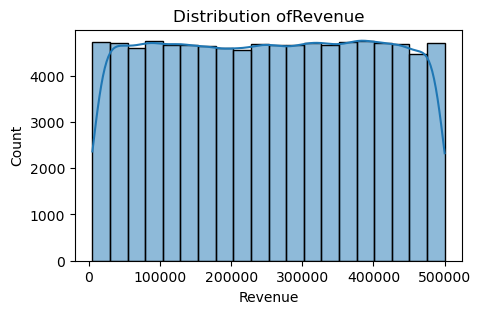

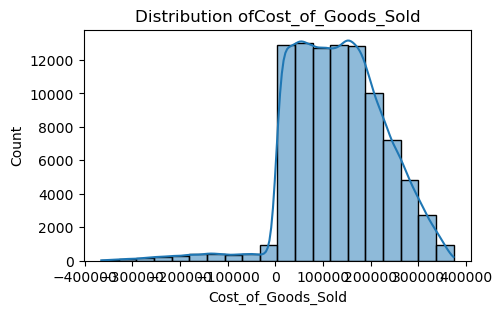

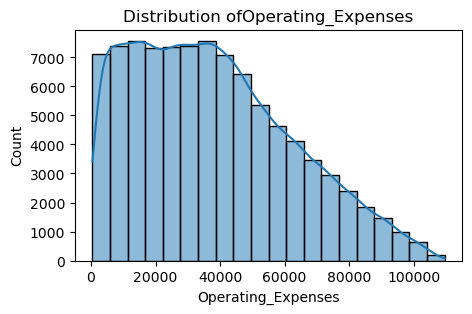

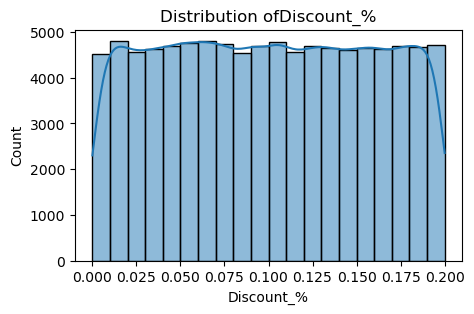

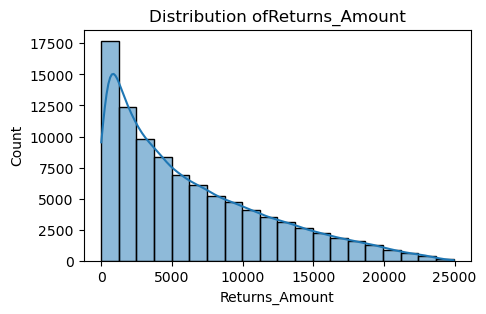

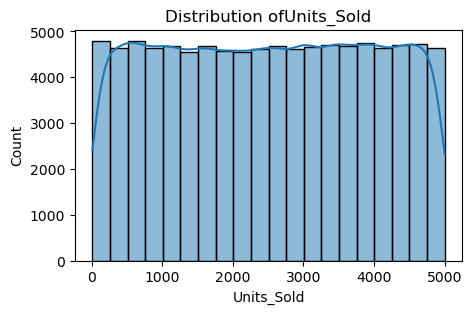

In [23]:
for col in numeric_col:
    plt.figure(figsize = (5,3))
    sns.histplot(fin[col],kde=True,bins = 20)
    plt.title(f'Distribution of{col}')
    plt.show()

In [24]:
# STEP 6: HANDLE OUTLIERS (IQR Method)


In [25]:
def remove_outliers_iqr(fin, column):
    Q1 = fin[column].quantile(0.25)
    Q3 = fin[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(fin)
    fin_clean = fin[(fin[column] >= lower) & (fin[column] <= upper)]
    removed = before - len(fin_clean)
    print(f"  {column:<25} | Lower: {lower:>10.2f} | Upper: {upper:>10.2f} | Removed: {removed}")
    return fin_clean
 
for col in ['Revenue', 'Cost_of_Goods_Sold', 'Operating_Expenses']:
    fin = remove_outliers_iqr(fin, col)
 
fin.reset_index(drop=True, inplace=True)
print(f"\nFinal row count after outlier removal: {len(fin)}")

  Revenue                   | Lower: -243781.46 | Upper:  748095.53 | Removed: 0
  Cost_of_Goods_Sold        | Lower: -141713.58 | Upper:  400199.78 | Removed: 1215
  Operating_Expenses        | Lower:  -37247.35 | Upper:  108645.89 | Removed: 8

Final row count after outlier removal: 92110


In [26]:
fin.describe()

,Date,Revenue,Cost_of_Goods_Sold,Operating_Expenses,Tax_Rate,Discount_%,Returns_Amount,Units_Sold
count,92110,92110.000000,92110.000000,92110.000000,92110.000000,92110.000000,92110.000000,92110.000000
mean,2022-06-15 23:28:05.523829760,250682.389180,135482.145524,37586.622555,0.239936,0.099985,6269.592169,2505.274237
min,2020-01-01 00:00:00,5001.100000,-141710.900000,414.160000,0.180000,0.000000,0.010000,10.000000
25%,2021-03-01 00:00:00,126688.557500,64176.197500,17459.060000,0.209900,0.050300,1750.372500,1246.000000
50%,2022-06-01 00:00:00,250231.710000,130874.430000,34614.655000,0.240000,0.099900,4681.325000,2513.000000
75%,2023-10-01 00:00:00,374469.762500,197983.475000,53927.847500,0.269900,0.150000,9566.895000,3759.000000
max,2024-12-01 00:00:00,499999.170000,373961.850000,108552.220000,0.300000,0.200000,24925.010000,5000.000000
std,NaN,142865.845016,88797.141965,24372.409084,0.034599,0.057706,5476.192093,1445.407460


In [27]:
# STEP 7: FEATURE ENGINEERING


In [28]:
fin['Gross_Profit']       = (fin['Revenue'] - fin['Cost_of_Goods_Sold'] ).round(2)
fin['EBIT']               =( fin['Gross_Profit'] - fin['Operating_Expenses']).round(2)
fin['Tax_Amount']         = (fin['EBIT'] * fin['Tax_Rate']).clip(lower=0).round(2)
fin['Tax_Rate']      = fin['Tax_Rate'].round(2)
fin['Net_Profit']         = (fin['EBIT'] - fin['Tax_Amount']).round(2)
fin['Gross_Margin_%']     = (fin['Gross_Profit'] / fin['Revenue'] * 100).round(2)
fin['Net_Profit_Margin_%'] = (fin['Net_Profit'] / fin['Revenue'] * 100).round(2)
fin['Revenue_Per_Unit']   = (fin['Revenue'] / fin['Units_Sold']).round(2)
fin['Date'] = pd.to_datetime(fin['Date'])
fin['Quarter'] = fin['Date'].dt.quarter.map({1:'Q1', 2:'Q2', 3:'Q3', 4:'Q4'})
fin['Year']               = fin['Date'].dt.year
fin['Month_Name']         = fin['Date'].dt.strftime('%b')

print("New columns added:")
new_cols = ['Gross_Profit', 'EBIT', 'Net_Profit', 'Gross_Margin_%',
            'Net_Profit_Margin_%', 'Revenue_Per_Unit', 'Quarter', 'Year', 'Month_Name']
for c in new_cols:
    print(f"  ✔ {c}")

New columns added:
  ✔ Gross_Profit
  ✔ EBIT
  ✔ Net_Profit
  ✔ Gross_Margin_%
  ✔ Net_Profit_Margin_%
  ✔ Revenue_Per_Unit
  ✔ Quarter
  ✔ Year
  ✔ Month_Name


In [29]:
# STEP 9: EXPORT CLEAN DATA


In [31]:
output_cols = [
    'Transaction_ID', 'Year', 'Month_Name', 'Quarter',
    'Region','Sales_Channel','Payment_Method','Customer_Type', 'Product_Category', 'Sales_Rep',
    'Revenue', 'Cost_of_Goods_Sold', 'Operating_Expenses',
    'Gross_Profit', 'EBIT', 'Tax_Rate', 'Tax_Amount', 'Net_Profit',
    'Gross_Margin_%', 'Net_Profit_Margin_%',
    'Units_Sold', 'Revenue_Per_Unit'
]
fin_final = fin[output_cols].copy()
fin_final.to_csv('financial_data_clean.csv', index=False) 

In [32]:
print("\n─── FINAL SUMMARY STATISTICS ───")
summary = fin_final[['Revenue', 'Net_Profit', 'Gross_Margin_%', 'Net_Profit_Margin_%']].describe().round(2)
print(summary.to_string())


─── FINAL SUMMARY STATISTICS ───
         Revenue  Net_Profit  Gross_Margin_%  Net_Profit_Margin_%
count   92110.00    92110.00        92110.00             92110.00
mean   250682.39    58986.95           46.67                24.07
std    142865.85    45084.36           17.70                13.84
min      5001.10      177.22           25.00                 2.16
25%    126688.56    23227.84           35.13                15.27
50%    250231.71    48823.38           45.27                22.99
75%    374469.76    85401.70           55.50                30.72
max    499999.17   388417.54          174.95               132.74
